In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import nibabel as nib
from scipy import stats
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
# parcels_of_interest = {
#     # From previous resting state paper: 133, 172, 9

#     'theory' : [133,172,192,284,339,395],
#     'data_driven' : [9,67,176,183,231,242,341,343,348,380,386,389,391]
# }

parcels_of_interest = [9,133,172]

variables = {
    'GPA': 'GPA',
    'Age': 'age',
    'Years of Experience': 'years_experience',
    'Code Editing' : 'code_editing_rate',
    'Prose Editing' : 'prose_editing_rate',
    'Code Total Keystrokes' : 'code_total_keystrokes',
    'Prose Total Keystrokes' : 'prose_total_keystrokes',
    'Correct' : 'correct',
    'Complete' : 'complete',
    'Code Correct' : 'code_correct',
    'Code Complete' : 'code_complete'
}



best_models = ['code-deepseek_6b-ndelays_10-look_ahead_by_0',
               'prose-starcoder2_7b-ndelays_16-look_ahead_by_3'
               ]

with open("/data/zachkaras/fmri_model_data/intermediate_results/parcels_of_interest-correlations.pkl", 'rb') as f:
    parcel_correlations = pickle.load(f)

In [3]:
with open('typing_counts.pkl', 'rb') as f:
    typing_counts = pickle.load(f)

demo_data = pd.read_csv("/home/zachkaras/fmri_model/master-survey-data.csv")
demo_data['years_experience'] = demo_data['semesters_experience'] / 2
demo_data = demo_data.set_index('id')

# Add keystroke-based variables to demo_data (separately for code and prose)
for pid_str, tasks in typing_counts.items():
    pid = int(pid_str)
    if pid not in demo_data.index:
        continue
    for task in ['code', 'prose']:
        try:
            total_keys = tasks[task]['total_keys_pressed']
        except:
            print(f"No {task} task for {pid}.")
            continue
        total_backspaces = tasks[task]['total_backspaces']
        demo_data.loc[pid, f'{task}_total_keystrokes'] = total_keys
        demo_data.loc[pid, f'{task}_editing_rate'] = total_backspaces / total_keys if total_keys > 0 else float('nan')

No prose task for 101.
No code task for 130.


In [4]:
participant_means = {}

for m in best_models:

    participant_means[m] = {parcel: {} for parcel in parcels_of_interest}

    parts = m.split('-')
    task, model, delays, look_ahead = parts[0], parts[1], parts[2], parts[3]

    mask = ((parcel_correlations['task'] == task) &
            (parcel_correlations['model'] == model) &
            (parcel_correlations['ndelays'] == delays) &
            (parcel_correlations['look_ahead'] == look_ahead))
    for p, df in parcel_correlations[mask].groupby(['participant']):
        p = p[0]
        for parcel in parcels_of_interest:
            parcel_mean = df[parcel].explode().mean()
            participant_means[m][parcel][p] = parcel_mean

In [5]:
import matplotlib.cm as cm
palette = [cm.rainbow(x) for x in np.linspace(0, 1, len(list(variables.keys())))]   
rng = np.random.default_rng(seed=474)                                                                                                                                                                      
rng.shuffle(palette)

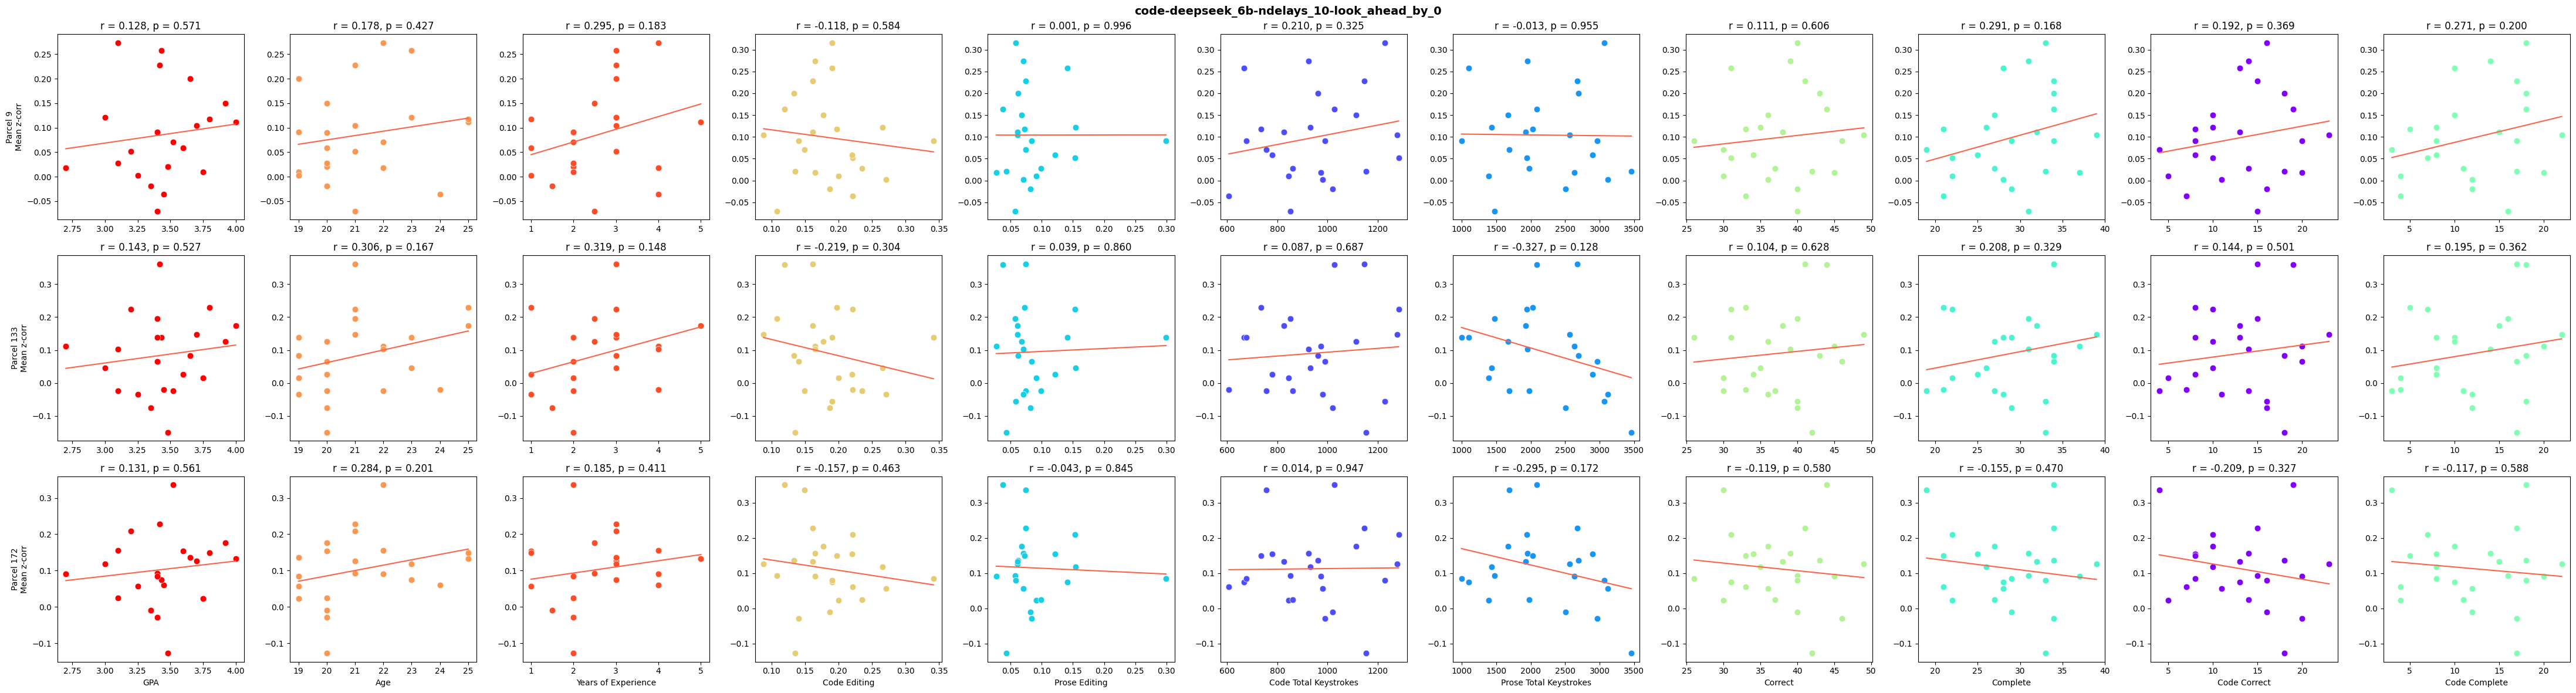

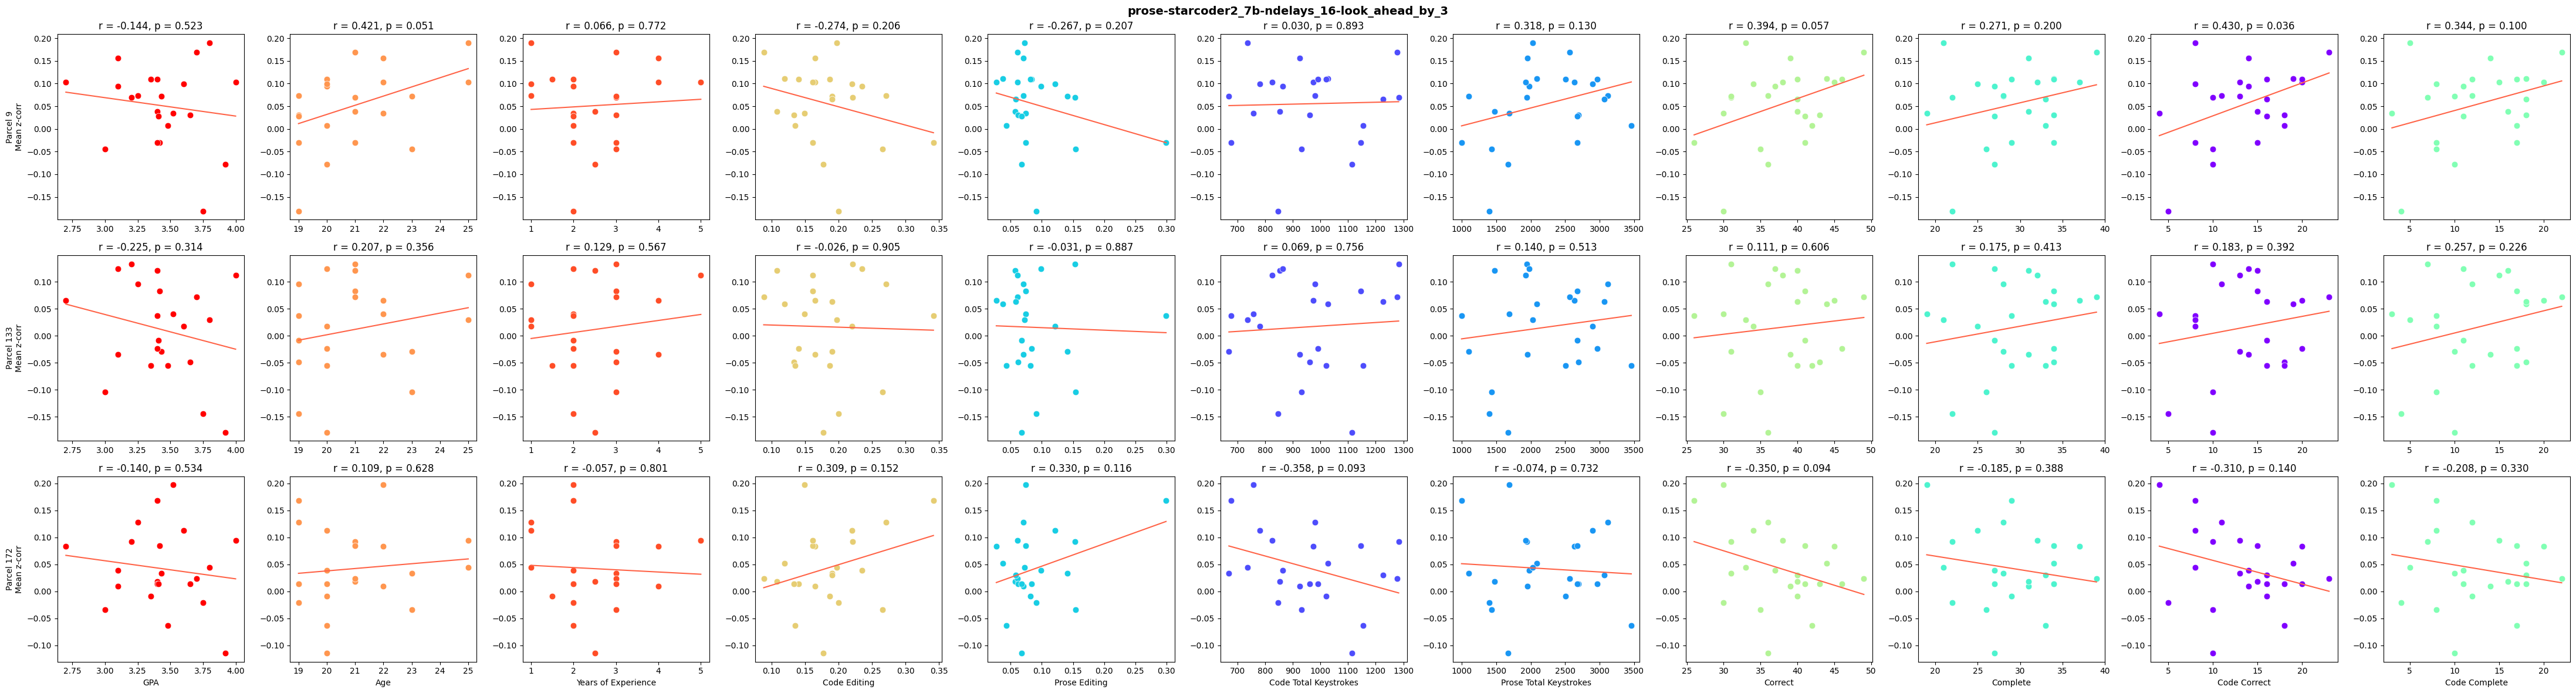

In [6]:
for m in best_models:
    fig, axes = plt.subplots(
        len(parcels_of_interest), len(variables),
        figsize=(4 * len(variables), 4 * len(parcels_of_interest))
    )
    fig.suptitle(m, fontsize=14, fontweight='bold')
    parts = m.split('-')
    task, model, delays, look_ahead = parts[0], parts[1], parts[2], parts[3]


    for row_idx, parcel in enumerate(parcels_of_interest):
        performance = participant_means[m][parcel]  # {pid_str: value}
        pids_int = [int(p) for p in performance.keys()]
        common_ids = [pid for pid in pids_int if pid in demo_data.index]
        brain_vals = np.array([performance[str(pid)] for pid in common_ids])

        for col_idx, (color, (var_label, col)) in enumerate(zip(palette, variables.items())):
            ax = axes[row_idx, col_idx]
            demo_vals = demo_data.loc[common_ids, col].values.astype(float)

            mask = ~np.isnan(demo_vals)
            x, y = demo_vals[mask], brain_vals[mask]

            r, p = stats.pearsonr(x, y)

            ax.scatter(x, y, color=color, edgecolors='white', linewidths=0.5, s=60)
            m_fit, b_fit = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, m_fit * x_line + b_fit, color='tomato', linewidth=1.5)

            ax.set_xlabel(var_label if row_idx == len(parcels_of_interest) - 1 else '')
            ax.set_ylabel(f'Parcel {parcel}\nMean z-corr' if col_idx == 0 else '')
            ax.set_title(f"r = {r:.3f}, p = {p:.3f}")

    plt.tight_layout()
    plt.savefig(f"/data/zachkaras/fmri_model_data/plots/corr_parcels_{task}.png", dpi=200, bbox_inches='tight')
    plt.show()